## 1. Load Data and Initial Exploration

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/tech_layoffs_hiring_trends_elite_v2.csv')

print('Dataset Head:')
display(df.head())

print('\nDataset Info:')
df.info()

print('\nDataset Description:')
display(df.describe(include='all'))

Dataset Head:


,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
0,T0,Microsoft,AI,Singapore,Enterprise,Mar,2026,860,1.8,AI Automation,...,Moderate Hiring,46.7,ML Engineer,-25.7,30.3,4.9,4.4,8.7,8.6,Bull Market
1,T1,Palantir,AI,Canada,Big Tech,Feb,2024,955,1.8,Cost Cutting,...,Moderate Hiring,58.9,ML Engineer,-5.6,6.1,1.5,1.0,8.2,7.2,Bull Market
2,T2,Anthropic,Cybersecurity,USA,Mid-size,Apr,2025,18912,9.5,Overhiring Correction,...,Hiring Freeze,85.4,Frontend Developer,7.0,-23.6,-14.9,5.6,4.5,5.9,Recession
3,T3,Spotify,Gaming,USA,Mid-size,Jun,2025,18159,9.1,Cost Cutting,...,Hiring Freeze,44.0,Frontend Developer,31.6,-22.3,-1.6,6.5,5.4,4.7,Recession
4,T4,Uber,Gaming,UK,Startup,Feb,2025,815,3.3,Market Slowdown,...,Moderate Hiring,53.2,Frontend Developer,85.3,26.6,9.8,9.3,6.7,5.8,Bull Market



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               12000 non-null  object 
 1   company_name            12000 non-null  object 
 2   industry                12000 non-null  object 
 3   country                 12000 non-null  object 
 4   company_size            12000 non-null  object 
 5   month                   12000 non-null  object 
 6   year                    12000 non-null  int64  
 7   layoffs_count           12000 non-null  int64  
 8   layoff_percentage       12000 non-null  float64
 9   reason_for_layoffs      12000 non-null  object 
 10  ai_automation_impact    12000 non-null  float64
 11  ai_replacement_risk     12000 non-null  float64
 12  open_roles              12000 non-null  int64  
 13  hiring_trend            12000 non-null  object 
 14  remote_jobs_percentage 

,record_id,company_name,industry,country,company_size,month,year,layoffs_count,layoff_percentage,reason_for_layoffs,...,hiring_trend,remote_jobs_percentage,top_hiring_role,stock_growth_percent,revenue_growth_percent,salary_budget_change,ai_adoption_level,employee_sentiment,job_security_score,market_condition
count,12000,12000,12000,12000,12000,12000,12000.000000,12000.000000,12000.000000,12000,...,12000,12000.000000,12000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000
unique,12000,20,7,6,4,12,NaN,NaN,NaN,5,...,4,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,3
top,T11983,Databricks,Social Media,Singapore,Big Tech,Feb,NaN,NaN,NaN,AI Automation,...,Hiring Freeze,NaN,ML Engineer,NaN,NaN,NaN,NaN,NaN,NaN,Stable
freq,1,644,1742,2043,3066,1053,NaN,NaN,NaN,2435,...,4975,NaN,2190,NaN,NaN,NaN,NaN,NaN,NaN,4078
mean,NaN,NaN,NaN,NaN,NaN,NaN,2024.998750,5009.572083,12.780125,NaN,...,NaN,50.205150,NaN,22.466550,17.469175,5.920392,5.538750,6.496217,5.805033,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.817703,5159.360491,10.212612,NaN,...,NaN,23.299575,NaN,38.814405,24.359448,11.777264,2.583047,1.582356,1.649677,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,0.000000,0.000000,NaN,...,NaN,10.000000,NaN,-45.000000,-25.000000,-28.000000,1.000000,1.300000,1.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2024.000000,1369.500000,5.100000,NaN,...,NaN,29.800000,NaN,-11.200000,-3.500000,-2.700000,3.300000,5.400000,4.700000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2025.000000,2733.000000,9.400000,NaN,...,NaN,50.500000,NaN,22.600000,17.500000,5.900000,5.600000,6.500000,5.900000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2026.000000,6490.000000,17.300000,NaN,...,NaN,70.700000,NaN,55.700000,38.400000,14.600000,7.700000,7.600000,7.000000,NaN


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Drop columns with too many missing values or irrelevant for prediction
df = df.drop(columns=['company_name', 'company_logo_url', 'news_url', 'company_link', 'record_id'], errors='ignore')

# Identify target variable and features
TARGET_COLUMN = 'ai_automation_impact' # Updated target column to a continuous variable

if TARGET_COLUMN not in df.columns:
    print(f"Error: Target column '{TARGET_COLUMN}' not found.")
else:
    y = df[TARGET_COLUMN]
    # Drop other highly correlated or target-related columns if they exist and are not features
    # Explicitly drop 'had_layoffs' if it exists, as it was a previous target and not relevant here
    columns_to_drop_from_X = [TARGET_COLUMN, 'layoffs_count', 'layoff_percentage', 'had_layoffs']
    X = df.drop(columns=columns_to_drop_from_X, errors='ignore')

    date_columns = X.select_dtypes(include=['object']).columns[X.select_dtypes(include=['object']).apply(lambda col: col.astype(str).str.match(r'\d{4}-\d{2}-\d{2}').any()).fillna(False)].tolist()

    for col in date_columns:
        X[col] = pd.to_datetime(X[col], errors='coerce')
        X[col + '_year'] = X[col].dt.year
        X[col + '_month'] = X[col].dt.month
        X[col + '_day'] = X[col].dt.day
        X = X.drop(columns=[col])

    # Identify categorical and numerical features
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numerical_features = X.select_dtypes(include=np.number).columns.tolist()

    if 'month' in numerical_features:
        numerical_features.remove('month')
    if 'month' not in categorical_features and 'month' in X.columns:
        categorical_features.append('month')

    # Create preprocessing pipelines for numerical and categorical features
    numerical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Create a preprocessor using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ])

    print(f"Target column '{TARGET_COLUMN}' selected. Proceeding with preprocessing.")

Target column 'ai_automation_impact' selected. Proceeding with preprocessing.


In [15]:
from sklearn.model_selection import train_test_split

# Removed stratify as it's not suitable for regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (9600, 18)
X_test shape: (2400, 18)
y_train shape: (9600,)
y_test shape: (2400,)


In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression # Added LinearRegression
from sklearn.impute import SimpleImputer

# Dictionary to store different model pipelines
models = {
    'RandomForestRegressor': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(random_state=42))
    ]),
    'LinearRegression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
}

# Train each model
for name, model_pipeline in models.items():
    print(f"Training {name}...")
    model_pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Training RandomForestRegressor...
RandomForestRegressor trained successfully.
Training LinearRegression...
LinearRegression trained successfully.



--- Evaluating RandomForestRegressor ---
Mean Absolute Error (MAE): 1.5065
Mean Squared Error (MSE): 3.7703
Root Mean Squared Error (RMSE): 1.9417
R2 Score: 0.7014


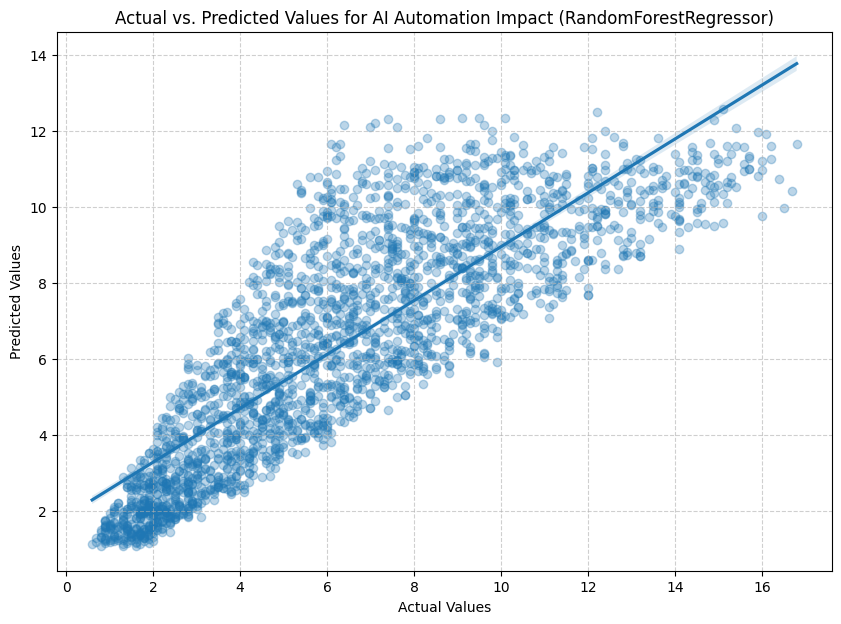

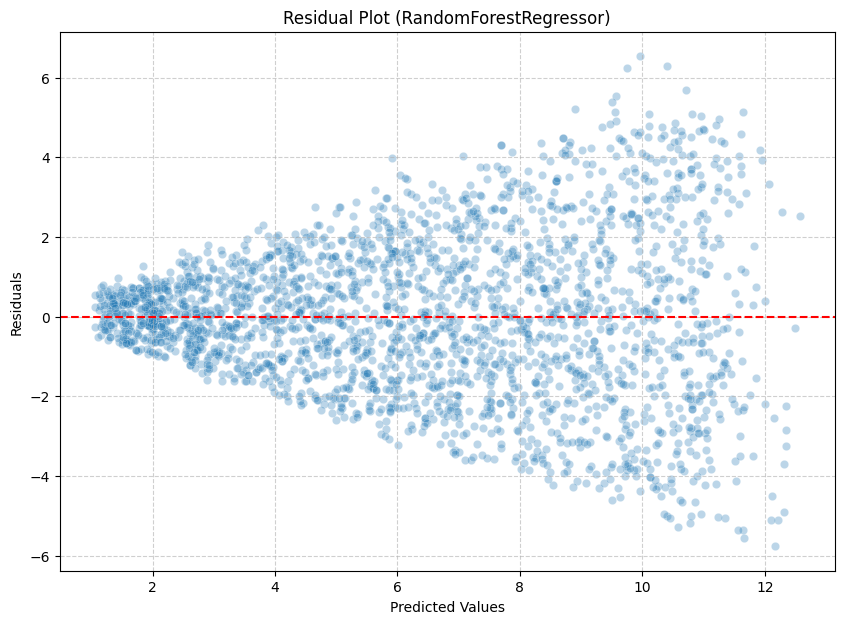


--- Evaluating LinearRegression ---
Mean Absolute Error (MAE): 1.4933
Mean Squared Error (MSE): 3.6895
Root Mean Squared Error (RMSE): 1.9208
R2 Score: 0.7078


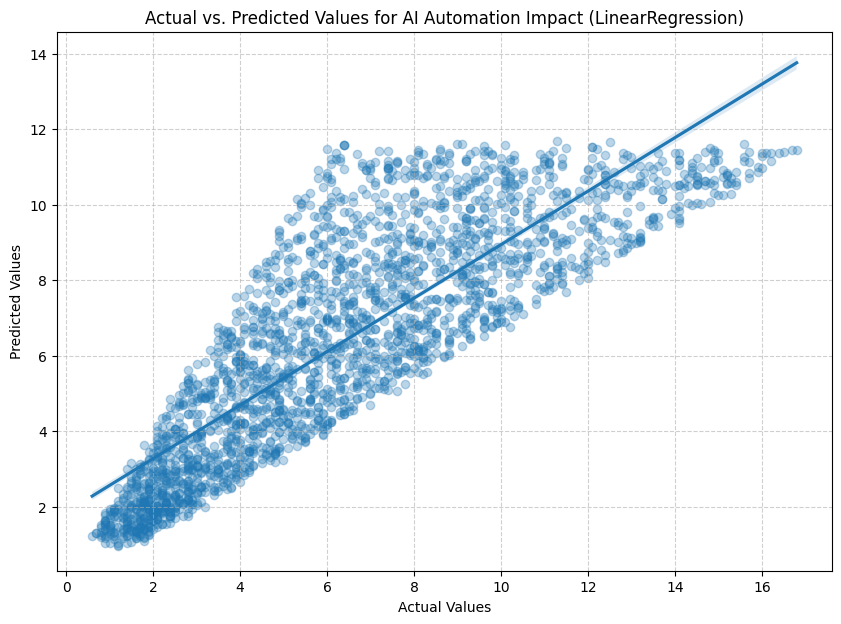

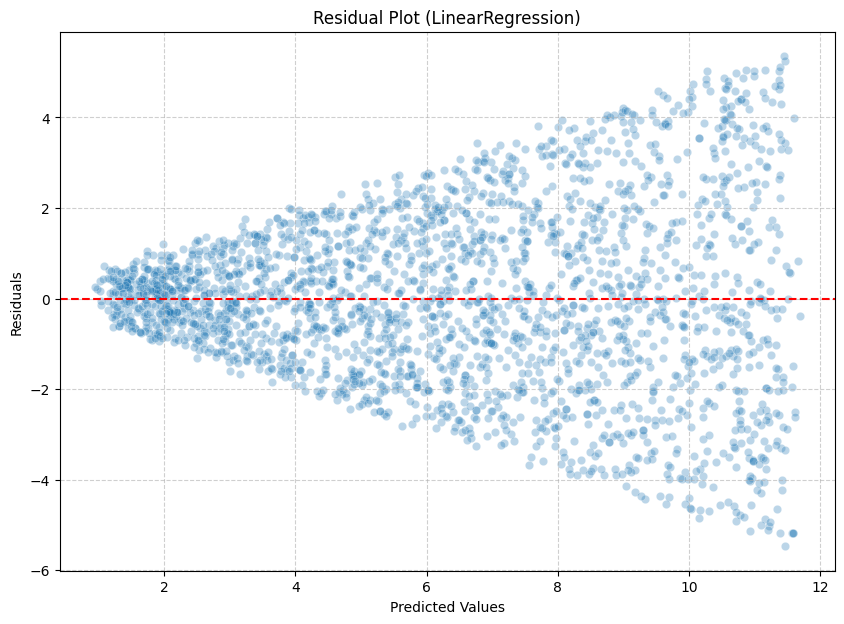

/tmp/ipykernel_1741/2689323518.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=metrics_df, palette='viridis')


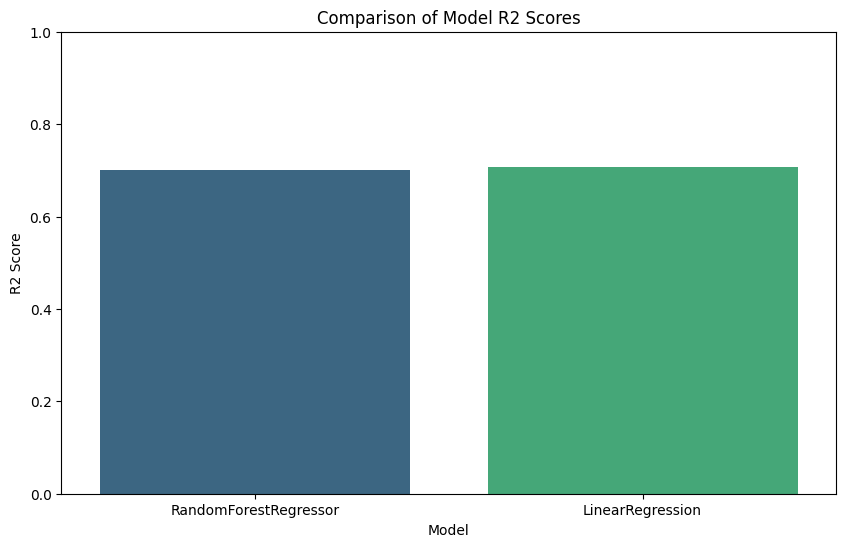

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

metrics_data = []

for name, model_pipeline in models.items():
    print(f"\n--- Evaluating {name} ---")

    # Make predictions
    y_pred = model_pipeline.predict(X_test)

    # Evaluate performance for regression
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics_data.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    # Visualize predictions vs actual values
    plt.figure(figsize=(10, 7))
    sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs. Predicted Values for AI Automation Impact ({name})')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Residual Plot
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot ({name})')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Comparison Graph: R2 Scores
metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=metrics_df, palette='viridis')
plt.ylabel('R2 Score')
plt.title('Comparison of Model R2 Scores')
plt.ylim(min(0, metrics_df['R2 Score'].min() - 0.1), 1)
plt.show()